Total orders loaded: 99,441
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Saved: C:\Users\Aditya Singh\ecommerce_funnel_analytics\outputs\dashboard.png
Saved: C:\Users\Aditya Singh\ecommerce_funnel_analytics\outputs\analysis_results.json

=== KEY FINDINGS ===
Total orders          : 99,441
Delivered (converted) : 96,478  (97.0%)
Canceled              : 625  (0.6%)
Avg order value       : R$137.04
Median order value    : R$86.57
Top category          : health_beauty
Top state             : SP  (40,501 orders)
Premium customers     : 3,079

✅ All outputs saved to: C:\Users\Aditya Singh\ecommerce_funnel_analytics\outputs


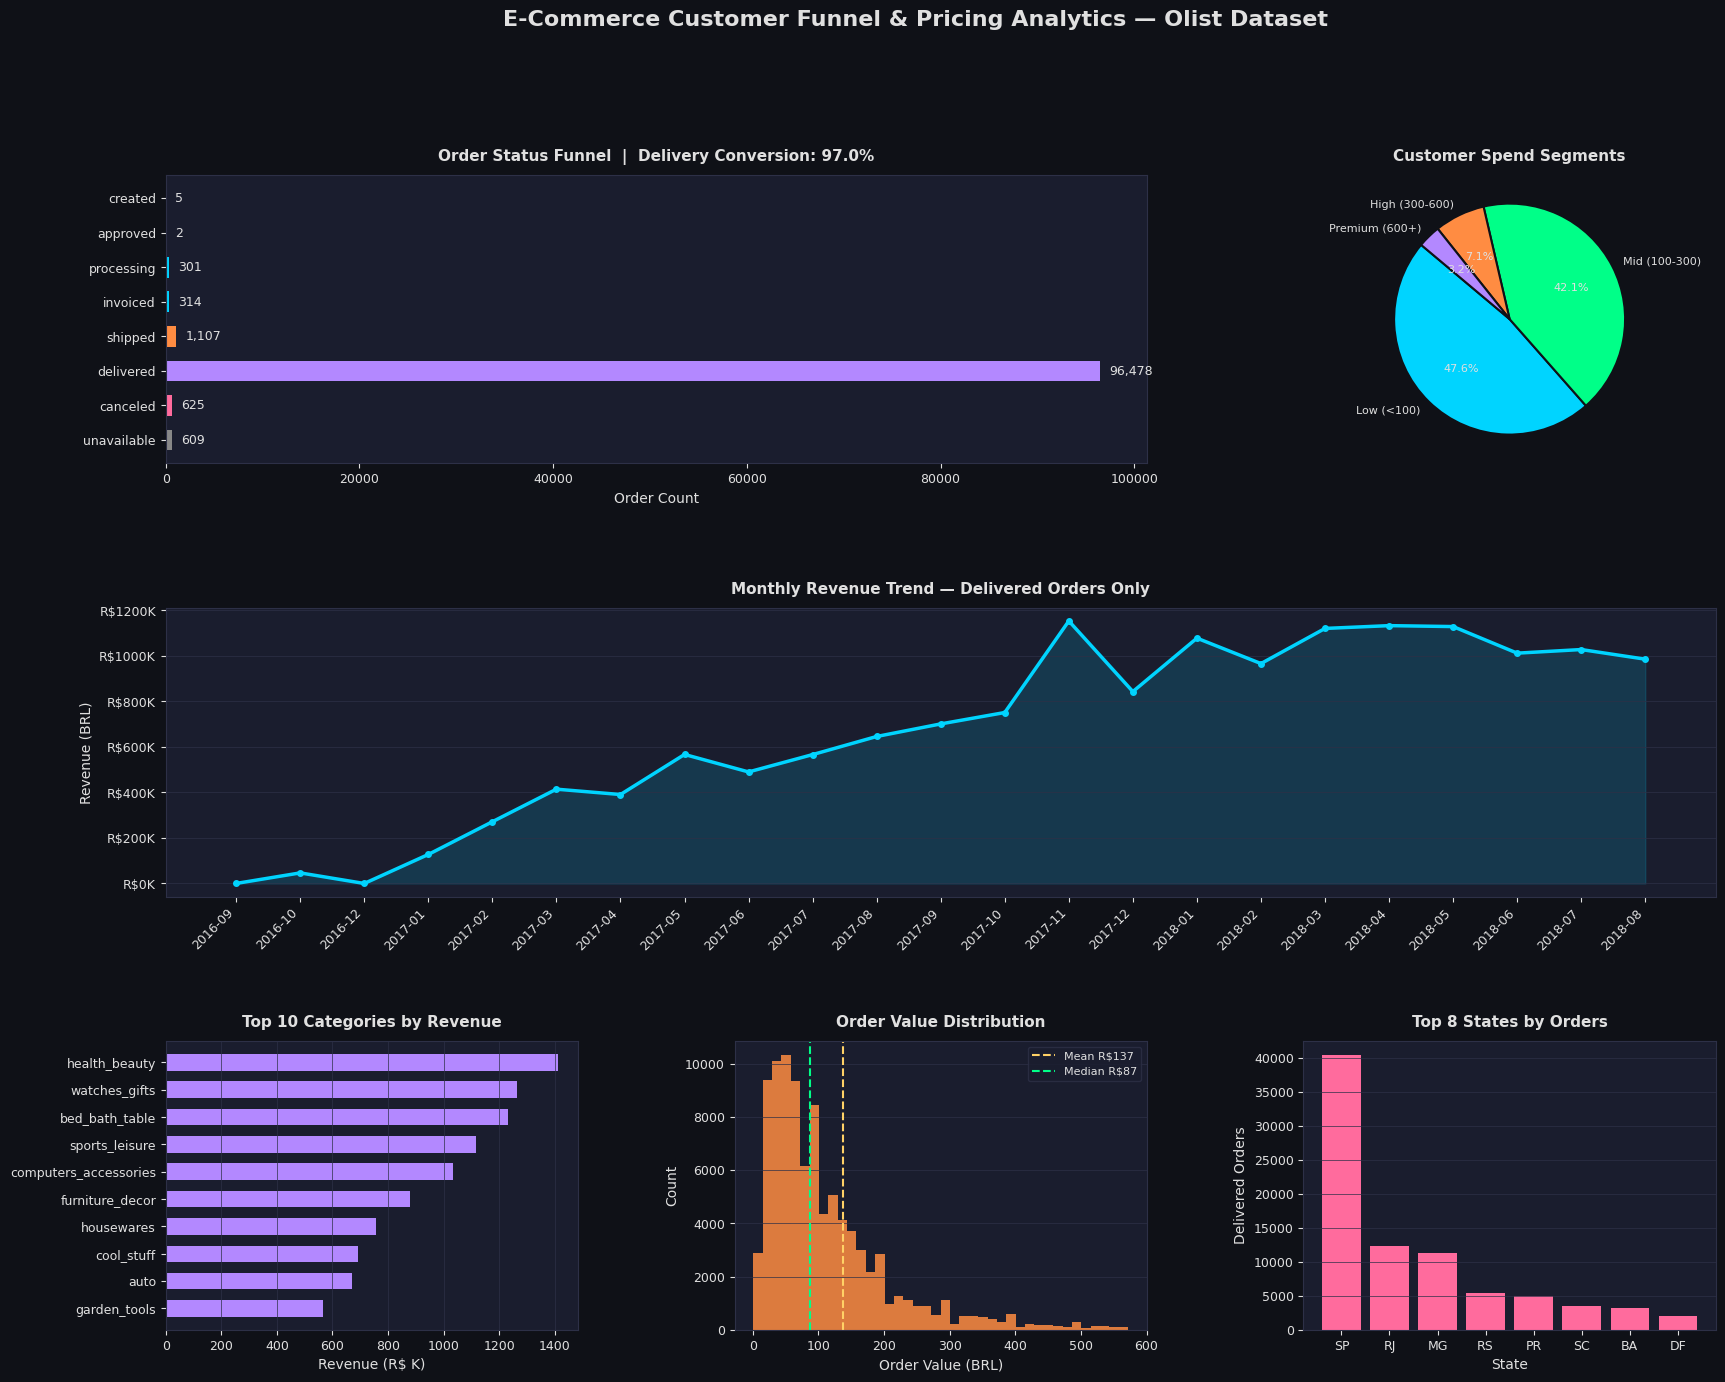

In [4]:
"""
E-Commerce Customer Funnel & Pricing Analytics
Real Dataset: Brazilian Olist (Kaggle)
Author: Aditya Singh
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import warnings
import json
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ── CONFIG — change this to your folder path ─────────────────────────────────
DATA_PATH = r"C:\Users\Aditya Singh\ecommerce_funnel_analytics"
OUTPUT_PATH = r"C:\Users\Aditya Singh\ecommerce_funnel_analytics\outputs"

# Create outputs folder if it doesn't exist
os.makedirs(OUTPUT_PATH, exist_ok=True)

def p(f): return f"{DATA_PATH}/{f}.csv"

# ── Load data ─────────────────────────────────────────────────────────────────
orders    = pd.read_csv(p("olist_orders_dataset"))
items     = pd.read_csv(p("olist_order_items_dataset"))
reviews   = pd.read_csv(p("olist_order_reviews_dataset"))
products  = pd.read_csv(p("olist_products_dataset"))
translate = pd.read_csv(p("product_category_name_translation"))
customers = pd.read_csv(p("olist_customers_dataset"))

# ── Clean & merge ─────────────────────────────────────────────────────────────

# Parse dates
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Translate product categories
products = products.merge(translate, on='product_category_name', how='left')
products['category'] = products['product_category_name_english'].fillna('unknown')

# Item-level: add category
items = items.merge(products[['product_id','category']], on='product_id', how='left')

# Order-level revenue: sum price + freight per order
order_revenue = items.groupby('order_id').agg(
    order_value=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    total_paid=('price', 'sum')   # we'll add freight below
).reset_index()
order_revenue['total_paid'] = order_revenue['order_value'] + order_revenue['freight_value']

# Top category per order (for category analysis)
top_cat = (items.groupby(['order_id','category'])['price'].sum()
           .reset_index().sort_values('price', ascending=False)
           .drop_duplicates('order_id')[['order_id','category']])

# Review: one score per order (take mean if duplicates)
review_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()

# Master order table
df = (orders
      .merge(order_revenue, on='order_id', how='left')
      .merge(top_cat,       on='order_id', how='left')
      .merge(review_agg,    on='order_id', how='left')
      .merge(customers[['customer_id','customer_state']], on='customer_id', how='left'))

df['order_value']  = df['order_value'].fillna(0)
df['total_paid']   = df['total_paid'].fillna(0)
df['review_score'] = df['review_score'].fillna(0)
df['category']     = df['category'].fillna('unknown')

print(f"Total orders loaded: {len(df):,}")
print(df['order_status'].value_counts())

# ── Analytics ─────────────────────────────────────────────────────────────────

# 1. Funnel
funnel_order = ['created','approved','processing','invoiced','shipped','delivered','canceled','unavailable']
funnel = df['order_status'].value_counts().reindex(funnel_order).fillna(0)
conversion_rate = funnel.get('delivered', 0) / len(df) * 100

# 2. Monthly revenue (delivered only)
monthly = (df[df.order_status == 'delivered']
           .groupby('month')['total_paid'].sum().reset_index())
monthly['month_str'] = monthly['month'].astype(str)

# 3. Category performance
cat_perf = (df[df.order_status == 'delivered']
            .groupby('category')
            .agg(revenue=('total_paid','sum'),
                 avg_review=('review_score','mean'),
                 orders=('order_id','count'))
            .sort_values('revenue', ascending=False)
            .head(10).reset_index())

# 4. Customer spend segmentation
cust_spend = (df[df.order_status == 'delivered']
              .groupby('customer_id')['total_paid'].sum().reset_index(name='total_spent'))
bins   = [0, 100, 300, 600, np.inf]
labels = ['Low (<100)', 'Mid (100-300)', 'High (300-600)', 'Premium (600+)']
cust_spend['segment'] = pd.cut(cust_spend['total_spent'], bins=bins, labels=labels)
seg_dist = cust_spend['segment'].value_counts().reindex(labels)

# 5. Order value distribution
del_orders = df[df.order_status == 'delivered']['order_value']

# 6. Top states by orders
top_states = df[df.order_status=='delivered']['customer_state'].value_counts().head(8)

# ── Dashboard ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 15))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(3, 3, hspace=0.50, wspace=0.38)

BG='#1a1d2e'; TEXT='#e0e0e0'
ACCENT='#00d4ff'; GREEN='#00ff88'; ORANGE='#ff8c42'
PURPLE='#b388ff'; PINK='#ff6b9d'; YELLOW='#ffd166'

def sax(ax, title):
    ax.set_facecolor(BG)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.set_title(title, color=TEXT, fontsize=11, fontweight='bold', pad=10)
    for s in ax.spines.values(): s.set_edgecolor('#2d3047')
    ax.yaxis.label.set_color(TEXT)
    ax.xaxis.label.set_color(TEXT)

# Panel 1: Funnel (horizontal bar)
ax1 = fig.add_subplot(gs[0, :2])
f_vals  = funnel.values
f_cols  = [GREEN, ACCENT, ACCENT, ACCENT, ORANGE, PURPLE, PINK, '#888888'][:len(funnel)]
bars = ax1.barh(funnel.index, f_vals, color=f_cols, height=0.6, edgecolor='none')
for bar, val in zip(bars, f_vals):
    if val > 0:
        ax1.text(bar.get_width() + max(f_vals)*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{int(val):,}', va='center', color=TEXT, fontsize=9)
ax1.set_xlabel('Order Count', color=TEXT)
ax1.invert_yaxis()
sax(ax1, f'Order Status Funnel  |  Delivery Conversion: {conversion_rate:.1f}%')

# Panel 2: Customer segments
ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(seg_dist.values, labels=seg_dist.index,
        colors=[ACCENT, GREEN, ORANGE, PURPLE],
        autopct='%1.1f%%', startangle=140,
        textprops={'color': TEXT, 'fontsize': 8},
        wedgeprops={'edgecolor': '#0f1117', 'linewidth': 1.5})
sax(ax2, 'Customer Spend Segments')

# Panel 3: Monthly revenue trend
ax3 = fig.add_subplot(gs[1, :])
x = range(len(monthly))
ax3.fill_between(x, monthly['total_paid'], alpha=0.15, color=ACCENT)
ax3.plot(x, monthly['total_paid'], color=ACCENT, lw=2.5, marker='o', ms=4)
ax3.set_xticks(list(x))
ax3.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=8)
ax3.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'R${v/1000:.0f}K'))
ax3.set_ylabel('Revenue (BRL)')
ax3.grid(axis='y', color='#2d3047', lw=0.5)
sax(ax3, 'Monthly Revenue Trend — Delivered Orders Only')

# Panel 4: Top 10 categories by revenue
ax4 = fig.add_subplot(gs[2, 0])
ax4.barh(cat_perf['category'][::-1], cat_perf['revenue'][::-1]/1000,
         color=PURPLE, height=0.6, edgecolor='none')
ax4.set_xlabel('Revenue (R$ K)')
ax4.grid(axis='x', color='#2d3047', lw=0.5)
sax(ax4, 'Top 10 Categories by Revenue')

# Panel 5: Order value distribution
ax5 = fig.add_subplot(gs[2, 1])
clipped = del_orders[del_orders < del_orders.quantile(0.97)]  # remove extreme outliers for viz
ax5.hist(clipped, bins=40, color=ORANGE, edgecolor='none', alpha=0.85)
ax5.axvline(del_orders.mean(), color=YELLOW, lw=1.5, linestyle='--', label=f'Mean R${del_orders.mean():.0f}')
ax5.axvline(del_orders.median(), color=GREEN, lw=1.5, linestyle='--', label=f'Median R${del_orders.median():.0f}')
ax5.legend(fontsize=8, labelcolor=TEXT, facecolor=BG, edgecolor='#2d3047')
ax5.set_xlabel('Order Value (BRL)')
ax5.set_ylabel('Count')
ax5.grid(axis='y', color='#2d3047', lw=0.5)
sax(ax5, 'Order Value Distribution')

# Panel 6: Top states by orders
ax6 = fig.add_subplot(gs[2, 2])
ax6.bar(top_states.index, top_states.values, color=PINK, edgecolor='none')
ax6.set_xlabel('State')
ax6.set_ylabel('Delivered Orders')
ax6.grid(axis='y', color='#2d3047', lw=0.5)
sax(ax6, 'Top 8 States by Orders')

fig.suptitle('E-Commerce Customer Funnel & Pricing Analytics — Olist Dataset',
             fontsize=16, fontweight='bold', color=TEXT, y=0.99)

# Save dashboard to outputs folder
dashboard_path = os.path.join(OUTPUT_PATH, 'dashboard.png')
plt.savefig(dashboard_path, dpi=150, bbox_inches='tight', facecolor='#0f1117')
print(f"\nSaved: {dashboard_path}")

# ── Export results as JSON ────────────────────────────────────────────────────

# Prepare data for JSON export
premium_label = 'Premium (600+)'
results = {
    "analysis_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "total_orders": int(len(df)),
    "delivered_orders": int(funnel.get('delivered', 0)),
    "conversion_rate": round(conversion_rate, 2),
    "canceled_orders": int(funnel.get('canceled', 0)),
    "canceled_rate": round(funnel.get('canceled', 0) / len(df) * 100, 2),
    "avg_order_value_brl": round(del_orders.mean(), 2),
    "median_order_value_brl": round(del_orders.median(), 2),
    "top_category": cat_perf.iloc[0]['category'],
    "top_category_revenue_brl": round(cat_perf.iloc[0]['revenue'], 2),
    "top_state": top_states.index[0],
    "top_state_orders": int(top_states.iloc[0]),
    "premium_customers": int((cust_spend['segment'] == premium_label).sum()),
    "order_status_funnel": funnel.to_dict(),
    "top_10_categories": cat_perf[['category', 'revenue', 'avg_review', 'orders']].to_dict(orient='records'),
    "customer_segments": {
        "Low (<100)": int(seg_dist.get('Low (<100)', 0)),
        "Mid (100-300)": int(seg_dist.get('Mid (100-300)', 0)),
        "High (300-600)": int(seg_dist.get('High (300-600)', 0)),
        "Premium (600+)": int(seg_dist.get(premium_label, 0))
    },
    "monthly_revenue": monthly[['month_str', 'total_paid']].rename(columns={'month_str': 'month', 'total_paid': 'revenue_brl'}).to_dict(orient='records'),
    "top_states": top_states.to_dict()
}

# Save JSON to outputs folder
json_path = os.path.join(OUTPUT_PATH, 'analysis_results.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"Saved: {json_path}")

# ── Print findings ────────────────────────────────────────────────────────────
print(f"\n=== KEY FINDINGS ===")
print(f"Total orders          : {len(df):,}")
print(f"Delivered (converted) : {int(funnel.get('delivered',0)):,}  ({conversion_rate:.1f}%)")
print(f"Canceled              : {int(funnel.get('canceled',0)):,}  ({funnel.get('canceled',0)/len(df)*100:.1f}%)")
print(f"Avg order value       : R${del_orders.mean():.2f}")
print(f"Median order value    : R${del_orders.median():.2f}")
print(f"Top category          : {cat_perf.iloc[0]['category']}")
print(f"Top state             : {top_states.index[0]}  ({top_states.iloc[0]:,} orders)")
print(f"Premium customers     : {(cust_spend.segment == premium_label).sum():,}")

print(f"\n✅ All outputs saved to: {OUTPUT_PATH}")